In [19]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score


In [20]:
# LOAD DATASET

data =  pd.read_csv("Watera.csv")


In [21]:
data.head(5)

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
0,7.14,440.98,614.26,2.12,208.39,350.92,7.22,17.32,2.23,0
1,6.41,242.82,387.89,3.93,313.10,153.36,9.92,20.69,2.07,0
2,6.29,133.09,225.55,1.46,332.04,1420.43,8.76,32.87,5.05,0
3,7.39,71.89,459.23,0.56,609.63,24142.89,9.62,42.80,2.26,0
4,6.31,273.01,308.99,0.64,52.59,196.85,1.05,133.38,5.30,0


In [22]:
# DIAGNOSIS KONDISI DATASET

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ph               96879 non-null   float64
 1   hardness         100000 non-null  float64
 2   tds              97616 non-null   float64
 3   chlorine         100000 non-null  float64
 4   sulfate          99187 non-null   float64
 5   conductivity     98402 non-null   float64
 6   organic_carbon   100000 non-null  float64
 7   trihalomethanes  100000 non-null  float64
 8   turbidity        100000 non-null  float64
 9   potability       100000 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 7.6 MB


In [23]:
data.describe()

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
count,96879.000000,100000.000000,97616.000000,100000.000000,99187.000000,98402.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,7.249512,309.214750,330.220307,2.500058,252.959861,2008.131292,7.198689,72.739011,3.139499,0.076160
std,0.995618,222.321384,246.036043,1.616047,152.955911,4028.651516,3.507656,50.389586,2.417457,0.265255
min,5.000000,0.000000,0.030000,0.000000,0.000000,0.040000,0.000000,0.000000,0.000000,0.000000
25%,6.490000,151.540000,160.547500,1.230000,137.920000,713.882500,4.710000,29.997500,1.450000,0.000000
50%,7.240000,271.080000,270.155000,2.410000,237.050000,1438.565000,7.300000,68.010000,2.660000,0.000000
75%,7.970000,391.580000,378.412500,3.570000,336.460000,2163.937500,9.840000,105.700000,4.300000,0.000000
max,9.990000,1099.990000,1099.990000,8.990000,799.970000,39961.990000,17.990000,229.960000,13.990000,1.000000


In [24]:
# Check Missing Value

# B. Mengecek Missing Values (Nilai Kosong/NaN)
print("Jumlah Missing Values per Kolom:")
print(data.isnull().sum()) 

# Mengetahui persentase missing values
print("\nPersentase Missing Values:")
print((data.isnull().sum() / len(data)) * 100)

# Mengetahui Kolom Mana saja yang memiliki Missing Values lebih dari 0
missing_values = data.isnull().sum()
missing_values[missing_values > 0]
	
# Identifikasi Missing Values dengan batas atas 75% (diatas sebaiknya dihapus saja)
# nilai 1000 tersebut bisa disesuaikan dengan Dataset yang dikerjakan
less = missing_values[missing_values < 1000].index
over = missing_values[missing_values >= 1000].index

# C. Mengecek Data Duplikat
print("\nJumlah baris duplikat:", data.duplicated().sum())
	

Jumlah Missing Values per Kolom:
ph                 3121
hardness              0
tds                2384
chlorine              0
sulfate             813
conductivity       1598
organic_carbon        0
trihalomethanes       0
turbidity             0
potability            0
dtype: int64

Persentase Missing Values:
ph                 3.121
hardness           0.000
tds                2.384
chlorine           0.000
sulfate            0.813
conductivity       1.598
organic_carbon     0.000
trihalomethanes    0.000
turbidity          0.000
potability         0.000
dtype: float64

Jumlah baris duplikat: 0


In [25]:
# DROP DUPLICATES DATA (Kalau ada)
data.drop_duplicates(inplace=True)

In [26]:
df = data.dropna(subset=['ph', 'tds', 'conductivity', 'sulfate'])
print(df.isnull().sum())

ph                 0
hardness           0
tds                0
chlorine           0
sulfate            0
conductivity       0
organic_carbon     0
trihalomethanes    0
turbidity          0
potability         0
dtype: int64


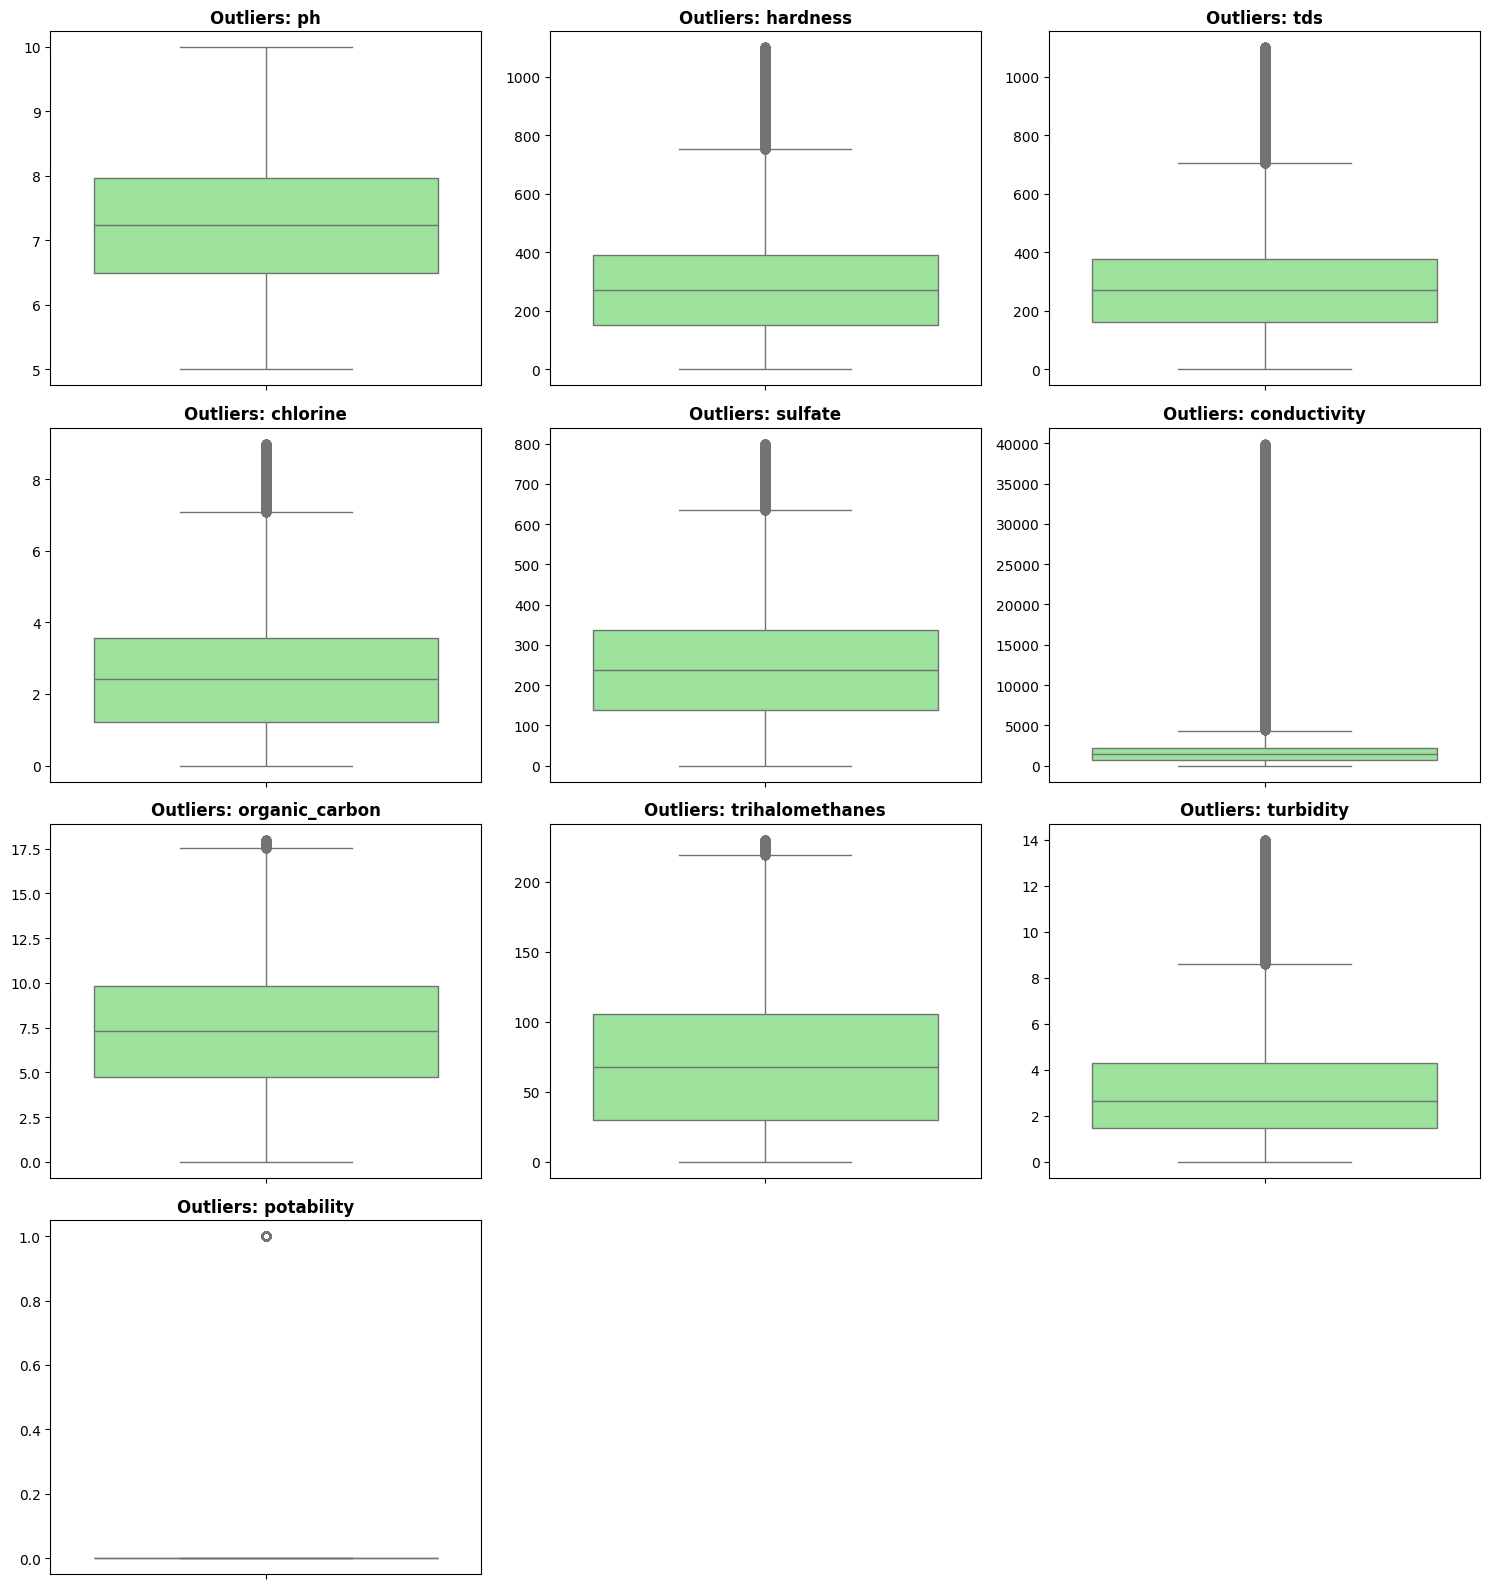

In [27]:
import pandas as pd
import math

numeric_features = df.select_dtypes(include=['number']).columns
categorical_features = df.select_dtypes(include=['object']).columns

jumlah_fitur = len(numeric_features)

# 2. Atur tata letak grid (misal: 3 kolom per baris)
kolom_grid = 3
baris_grid = math.ceil(jumlah_fitur / kolom_grid)

# 3. Buat kanvas (figure) dan kotak-kotaknya (axes)
# figsize diatur dinamis: lebar 15, tinggi menyesuaikan jumlah baris
fig, axes = plt.subplots(baris_grid, kolom_grid, figsize=(15, 4 * baris_grid))
axes = axes.flatten() # Ratakan array kotak agar mudah diisi pakai loop

# 4. Looping untuk menggambar boxplot Seaborn ke dalam masing-masing kotak
for i, col in enumerate(numeric_features):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Outliers: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('') # Sembunyikan label Y agar UI lebih bersih

# 5. Hapus kotak sisa yang kosong (jika total fitur Anda bukan kelipatan 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Rapikan jarak antar kotak dan tampilkan
plt.tight_layout()
plt.show()

In [28]:
## Handle Outliers

def cap_outliers_efficient(df, columns):
    df_capped = df.copy() # Membuat salinan agar data asli tidak rusak
    
    for col in columns:
        # Menentukan batas bawah (persentil 5%) dan atas (persentil 95%)
        lower_bound = df_capped[col].quantile(0.05)
        upper_bound = df_capped[col].quantile(0.95)
        
        # Fungsi clip() akan otomatis membatasi nilai yang kelebihan/kekurangan
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
        
    return df_capped

# Penggunaan:
df = cap_outliers_efficient(df, numeric_features)

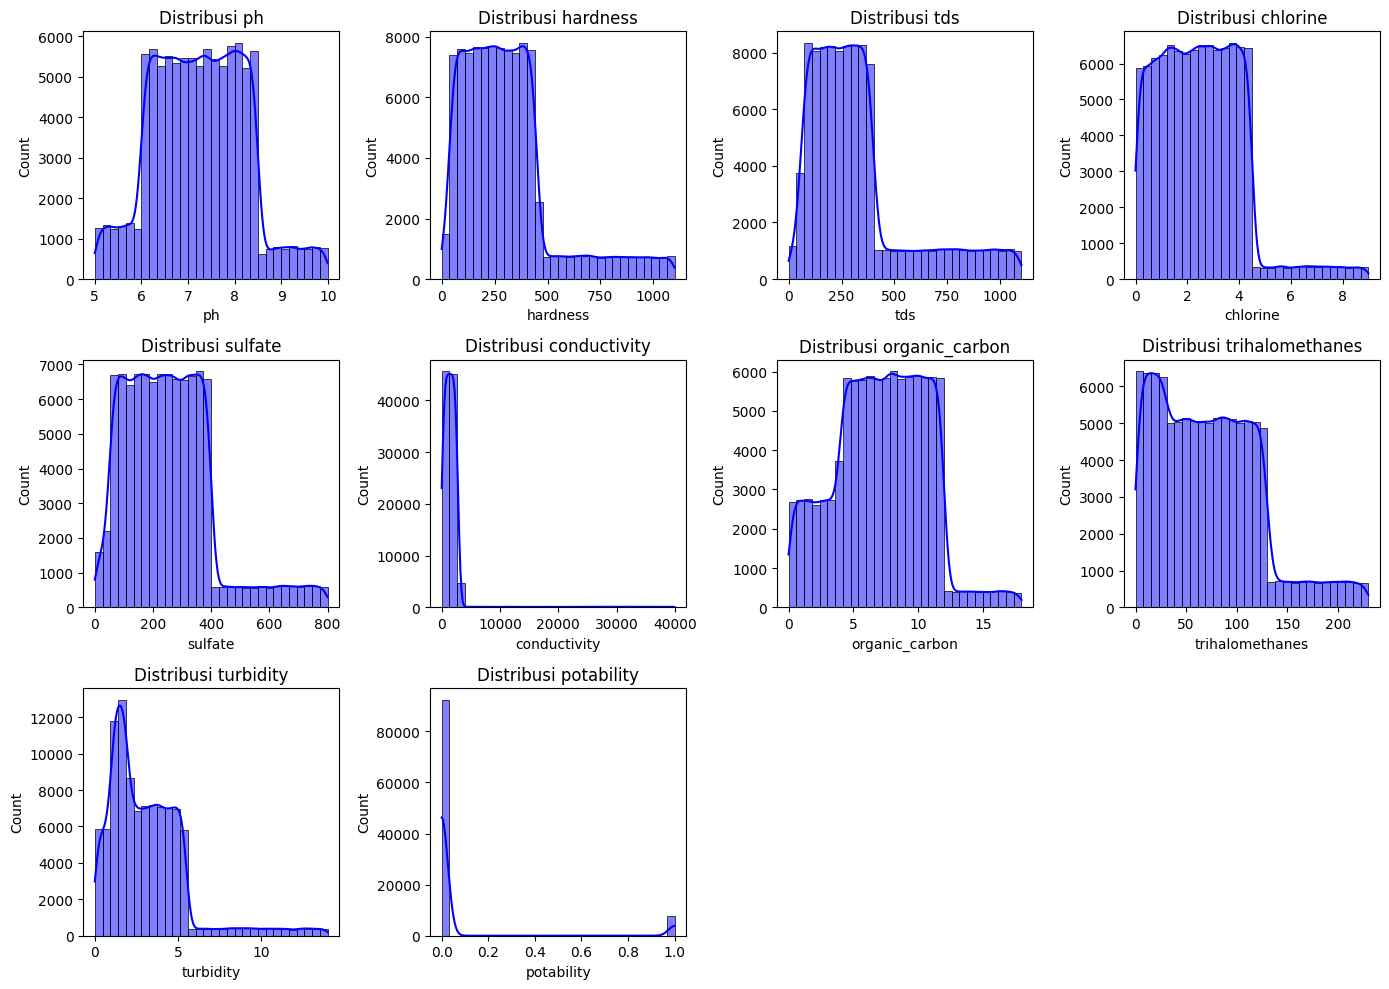

In [ ]:
# Distribusi fitur numerik
num_features =   df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
for i, column in enumerate(num_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(data[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

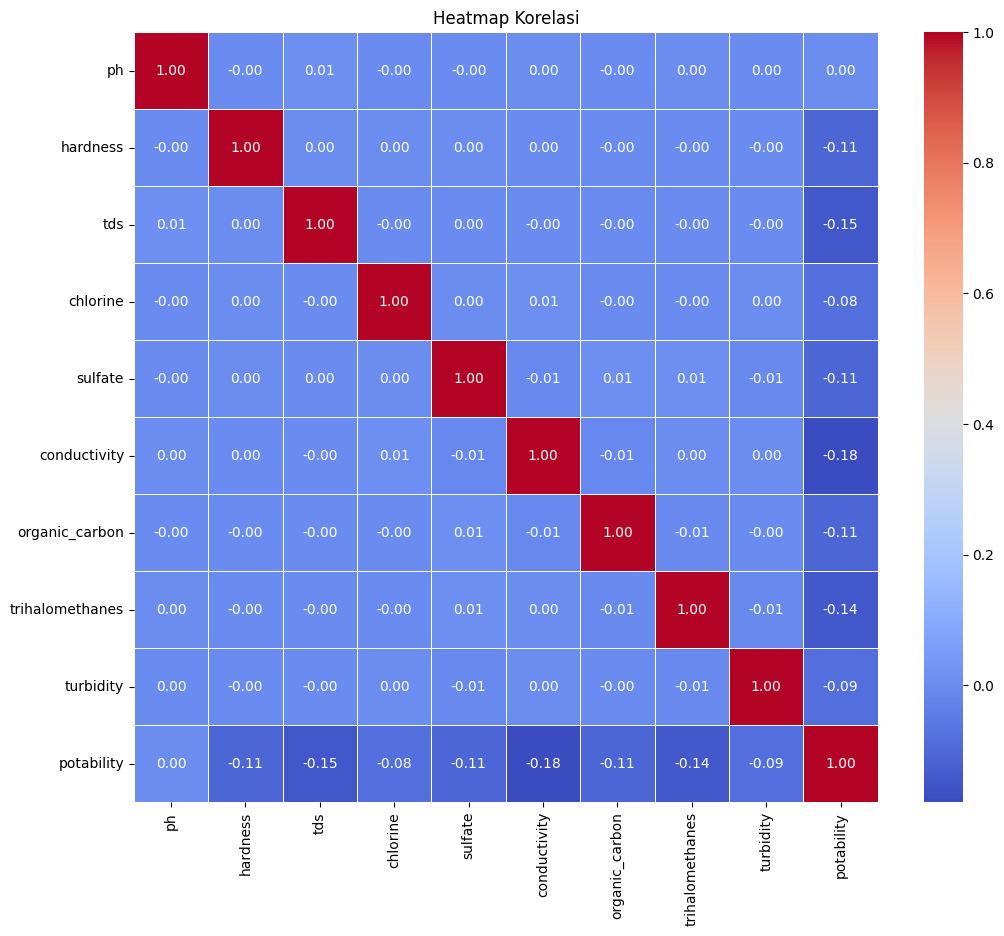

In [30]:
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

In [ ]:
# Karena sudah numerik semua, tidak perlu ada Encoding
# Splitting Dataset 
scaler = MinMaxScaler()

X = df.drop(columns='potability')
y = df['potability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8)

# normalisasi Fitur

numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numer])

In [32]:
# Model LOAD

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)
